In [1]:
import pandas as pd

In [13]:
all_variants = pd.read_csv("../data/all_sites.txt", sep="\t", header=None, dtype={4: str})
all_variants

,0,1,2,3,4
0,chr1,69081,G,C,11
1,chr1,69130,C,G,10
2,chr1,69134,A,G,11
3,chr1,69135,A,G,01
4,chr1,69155,T,C,01
...,...,...,...,...,...
8809571,chrY,25043920,G,A,10
8809572,chrY,25044016,G,A,10
8809573,chrY,25044035,T,C,10
8809574,chrY,25044040,T,A,10


In [14]:
all_variants[0].value_counts()

0
chr1     884909
chr2     637800
chr19    600859
chr11    525669
chr17    520291
chr3     492692
chr12    457527
chr16    434679
chr7     428044
chr6     421767
chr5     383849
chr9     379969
chr10    351957
chr4     330119
chr8     315433
chr15    303950
chr14    287826
chrX     253043
chr20    222156
chr22    205989
chr13    148503
chr18    132604
chr21     85957
chrY       3984
Name: count, dtype: int64

In [15]:
# VCF positions are 1 indexed, inclusive
# Changing to bed format
all_variants["start"] = all_variants[1] - 1
all_variants["end"] = all_variants[1]
all_variants

,0,1,2,3,4,start,end
0,chr1,69081,G,C,11,69080,69081
1,chr1,69130,C,G,10,69129,69130
2,chr1,69134,A,G,11,69133,69134
3,chr1,69135,A,G,01,69134,69135
4,chr1,69155,T,C,01,69154,69155
...,...,...,...,...,...,...,...
8809571,chrY,25043920,G,A,10,25043919,25043920
8809572,chrY,25044016,G,A,10,25044015,25044016
8809573,chrY,25044035,T,C,10,25044034,25044035
8809574,chrY,25044040,T,A,10,25044039,25044040


In [16]:
all_variants["chr"] = all_variants[0].str.split("chr").str[1]
all_variants

,0,1,2,3,4,start,end,chr
0,chr1,69081,G,C,11,69080,69081,1
1,chr1,69130,C,G,10,69129,69130,1
2,chr1,69134,A,G,11,69133,69134,1
3,chr1,69135,A,G,01,69134,69135,1
4,chr1,69155,T,C,01,69154,69155,1
...,...,...,...,...,...,...,...,...
8809571,chrY,25043920,G,A,10,25043919,25043920,Y
8809572,chrY,25044016,G,A,10,25044015,25044016,Y
8809573,chrY,25044035,T,C,10,25044034,25044035,Y
8809574,chrY,25044040,T,A,10,25044039,25044040,Y


In [17]:
all_variants[4].value_counts()

4
11    5268134
10    1848037
01    1693405
Name: count, dtype: int64

In [22]:
all_variants["proband"] = all_variants[4].str[0].astype(int).astype(bool)
all_variants["sibling"] = all_variants[4].str[1].astype(int).astype(bool)
all_variants

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,69081,G,C,11,69080,69081,1,True,True
1,chr1,69130,C,G,10,69129,69130,1,True,False
2,chr1,69134,A,G,11,69133,69134,1,True,True
3,chr1,69135,A,G,01,69134,69135,1,False,True
4,chr1,69155,T,C,01,69154,69155,1,False,True
...,...,...,...,...,...,...,...,...,...,...
8809571,chrY,25043920,G,A,10,25043919,25043920,Y,True,False
8809572,chrY,25044016,G,A,10,25044015,25044016,Y,True,False
8809573,chrY,25044035,T,C,10,25044034,25044035,Y,True,False
8809574,chrY,25044040,T,A,10,25044039,25044040,Y,True,False


In [30]:
all_variants[["proband", "sibling"]].value_counts()

proband  sibling
True     True       5268134
         False      1848037
False    True       1693405
Name: count, dtype: int64

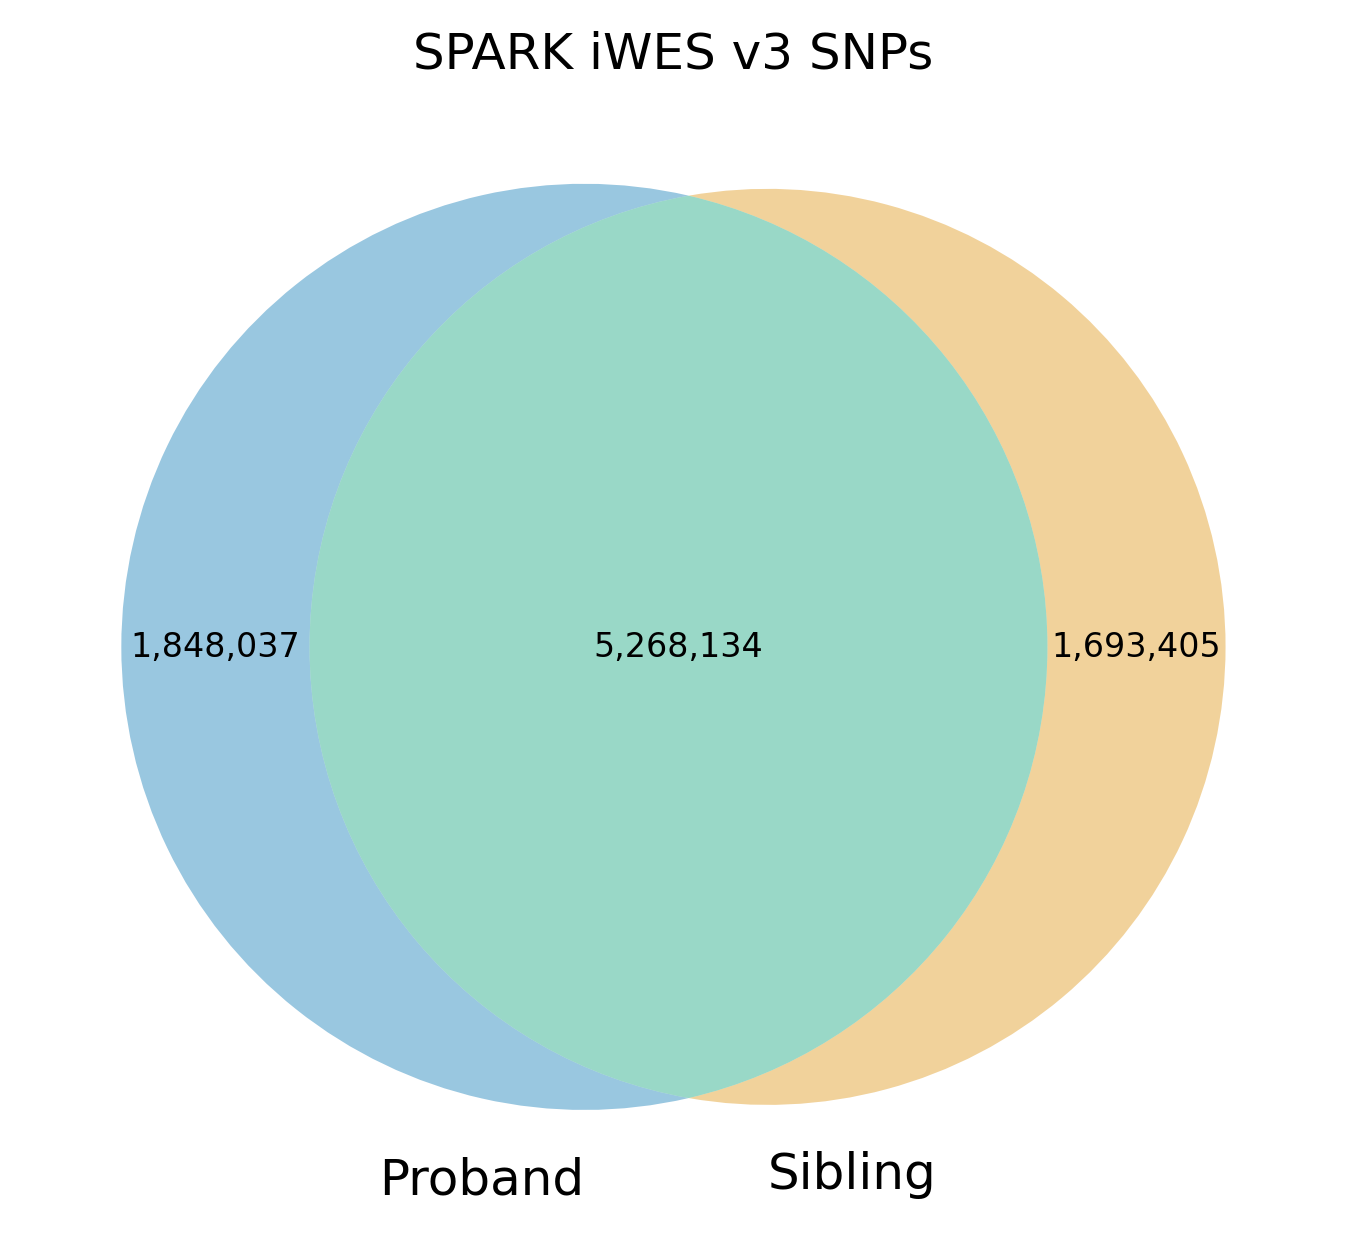

In [64]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts for the Venn diagram
value_counts = all_variants[["proband", "sibling"]].value_counts()

# Extract the counts for the sets
proband_only_count = value_counts.get((True, False), 0)
sibling_only_count = value_counts.get((False, True), 0)
both_count = value_counts.get((True, True), 0)

# Create the Venn diagram
#venn2(subsets=(proband_only_count, sibling_only_count, both_count), set_labels=("Proband", "Sibling"))

venn2_circles = venn2(
    subsets=(proband_only_count, sibling_only_count, both_count), 
    set_labels=("Proband", "Sibling")
)

# Format the counts as strings and add them to the diagram
venn2_circles.get_label_by_id('10').set_text(f"{proband_only_count:,}")
venn2_circles.get_label_by_id('01').set_text(f"{sibling_only_count:,}")
venn2_circles.get_label_by_id('11').set_text(f"{both_count:,}")

# Adjust font size for better fit

for label in venn2_circles.subset_labels:
    if label:
        label.set_fontsize(8)
colors = sns.color_palette('colorblind')

for subset_id, color in zip(['10', '01', '11'], colors[:3]):
    patch = venn2_circles.get_patch_by_id(subset_id)
    patch.set_color(color)
    patch.set_edgecolor("none")  # remove border


# Display the plot with dpi 300
plt.gcf().set_dpi(300)
plt.title("SPARK iWES v3 SNPs")
plt.show()

In [65]:
all_proband = all_variants[all_variants["proband"]]
all_proband

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,69081,G,C,11,69080,69081,1,True,True
1,chr1,69130,C,G,10,69129,69130,1,True,False
2,chr1,69134,A,G,11,69133,69134,1,True,True
6,chr1,69224,A,T,11,69223,69224,1,True,True
7,chr1,69265,C,A,10,69264,69265,1,True,False
...,...,...,...,...,...,...,...,...,...,...
8809571,chrY,25043920,G,A,10,25043919,25043920,Y,True,False
8809572,chrY,25044016,G,A,10,25044015,25044016,Y,True,False
8809573,chrY,25044035,T,C,10,25044034,25044035,Y,True,False
8809574,chrY,25044040,T,A,10,25044039,25044040,Y,True,False


In [78]:
all_proband_bed = all_proband[["chr", "start", "end",  2, 3]]
all_proband_bed["af"] = 0
all_proband_bed.to_csv("../soto_analysis/raw_files/all_proband.bed", header = None, index = 0, sep = "\t")
all_proband_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_98386/3031037463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_proband_bed["af"] = 0


,chr,start,end,2,3,af
0,1,69080,69081,G,C,0
1,1,69129,69130,C,G,0
2,1,69133,69134,A,G,0
6,1,69223,69224,A,T,0
7,1,69264,69265,C,A,0
...,...,...,...,...,...,...
8809571,Y,25043919,25043920,G,A,0
8809572,Y,25044015,25044016,G,A,0
8809573,Y,25044034,25044035,T,C,0
8809574,Y,25044039,25044040,T,A,0


In [66]:
all_sibling = all_variants[all_variants["sibling"]]
all_sibling

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,69081,G,C,11,69080,69081,1,True,True
2,chr1,69134,A,G,11,69133,69134,1,True,True
3,chr1,69135,A,G,01,69134,69135,1,False,True
4,chr1,69155,T,C,01,69154,69155,1,False,True
5,chr1,69218,T,C,01,69217,69218,1,False,True
...,...,...,...,...,...,...,...,...,...,...
8809565,chrY,24864495,A,T,11,24864494,24864495,Y,True,True
8809566,chrY,24864495,A,C,11,24864494,24864495,Y,True,True
8809567,chrY,24864540,G,T,11,24864539,24864540,Y,True,True
8809568,chrY,24864554,T,C,11,24864553,24864554,Y,True,True


In [75]:
all_sibling_bed = all_sibling[["chr", "start", "end",  2, 3]]
all_sibling_bed["af"] = 0
all_sibling_bed.to_csv("../soto_analysis/raw_files/all_sibling.bed", header = None, index = 0, sep = "\t")
all_sibling_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_98386/890169839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sibling_bed["af"] = 0


,chr,start,end,2,3,af
0,1,69080,69081,G,C,0
2,1,69133,69134,A,G,0
3,1,69134,69135,A,G,0
4,1,69154,69155,T,C,0
5,1,69217,69218,T,C,0
...,...,...,...,...,...,...
8809565,Y,24864494,24864495,A,T,0
8809566,Y,24864494,24864495,A,C,0
8809567,Y,24864539,24864540,G,T,0
8809568,Y,24864553,24864554,T,C,0


In [67]:
proband_only = all_proband[~all_proband["sibling"]]
proband_only

,0,1,2,3,4,start,end,chr,proband,sibling
1,chr1,69130,C,G,10,69129,69130,1,True,False
7,chr1,69265,C,A,10,69264,69265,1,True,False
9,chr1,69275,T,G,10,69274,69275,1,True,False
12,chr1,69335,G,A,10,69334,69335,1,True,False
28,chr1,69486,C,T,10,69485,69486,1,True,False
...,...,...,...,...,...,...,...,...,...,...
8809571,chrY,25043920,G,A,10,25043919,25043920,Y,True,False
8809572,chrY,25044016,G,A,10,25044015,25044016,Y,True,False
8809573,chrY,25044035,T,C,10,25044034,25044035,Y,True,False
8809574,chrY,25044040,T,A,10,25044039,25044040,Y,True,False


In [76]:
proband_only_bed = proband_only[["chr", "start", "end",  2, 3]]
proband_only_bed["af"] = 0
proband_only_bed.to_csv("../soto_analysis/raw_files/proband_only.bed", header = None, index = 0, sep = "\t")
proband_only_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_98386/190302568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proband_only_bed["af"] = 0


,chr,start,end,2,3,af
1,1,69129,69130,C,G,0
7,1,69264,69265,C,A,0
9,1,69274,69275,T,G,0
12,1,69334,69335,G,A,0
28,1,69485,69486,C,T,0
...,...,...,...,...,...,...
8809571,Y,25043919,25043920,G,A,0
8809572,Y,25044015,25044016,G,A,0
8809573,Y,25044034,25044035,T,C,0
8809574,Y,25044039,25044040,T,A,0


In [68]:
sibling_only = all_sibling[~all_sibling["proband"]]
sibling_only

,0,1,2,3,4,start,end,chr,proband,sibling
3,chr1,69135,A,G,01,69134,69135,1,False,True
4,chr1,69155,T,C,01,69154,69155,1,False,True
5,chr1,69218,T,C,01,69217,69218,1,False,True
10,chr1,69283,T,C,01,69282,69283,1,False,True
11,chr1,69322,T,C,01,69321,69322,1,False,True
...,...,...,...,...,...,...,...,...,...,...
8809541,chrY,23229652,C,T,01,23229651,23229652,Y,False,True
8809552,chrY,24806479,T,G,01,24806478,24806479,Y,False,True
8809557,chrY,24854927,G,A,01,24854926,24854927,Y,False,True
8809560,chrY,24864418,C,T,01,24864417,24864418,Y,False,True


In [77]:
sibling_only_bed = sibling_only[["chr", "start", "end",  2, 3]]
sibling_only_bed["af"] = 0
sibling_only_bed.to_csv("../soto_analysis/raw_files/sibling_only.bed", header = None, index = 0, sep = "\t")
sibling_only_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_98386/876680341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sibling_only_bed["af"] = 0


,chr,start,end,2,3,af
3,1,69134,69135,A,G,0
4,1,69154,69155,T,C,0
5,1,69217,69218,T,C,0
10,1,69282,69283,T,C,0
11,1,69321,69322,T,C,0
...,...,...,...,...,...,...
8809541,Y,23229651,23229652,C,T,0
8809552,Y,24806478,24806479,T,G,0
8809557,Y,24854926,24854927,G,A,0
8809560,Y,24864417,24864418,C,T,0
